# Notas de Estudio y Desarrollo: Quantum Machine Learning (QML)

Este cuaderno contiene notas de estudio, fundamentos de aprendizaje automático clásico e introducciones a modelos híbridos basados en los capítulos de QML del libro:
* **Manual:** *A Practical Guide to Quantum Machine Learning and Quantum Optimization* (Packt Publishing).
* **Autores:** Elías F. Combarro y Samuel González-Castillo.

### Contenido y Alcance
* **Bases de Machine Learning Tradicional:** Configuración de entornos de clasificación y regresión utilizando arquitecturas clásicas en TensorFlow y Keras.
* **Transición Cuántica:** Preparación de datasets para la carga de datos en clasificadores cuánticos (CQ) y redes neuronales híbridas.

## Capítulo 8: ¿Qué es el Quantum Machine Learning?

### 8.1 Conceptos básicos del Machine Learning

Para poder entrenar un sistema de aprendizaje automático, en la mayoría de los casos necesitamos reunir tres ingredientes fundamentales:

1. **El Modelo:** Necesitamos un algoritmo o modelo computacional que sea lo suficientemente potente para resolver nuestro problema. Este modelo tiene parámetros numéricos que podemos ajustar, como ocurre, por ejemplo, con el modelo del perceptrón.
2. **Los Datos:** Necesitamos datos con los que alimentar al modelo para que pueda ajustar sus parámetros. A las variables de entrada se las conoce como características (*features*), mientras que a la salida esperada se la conoce como etiqueta (*label*).
3. **La Función de Pérdida (Loss function):** Necesitamos una forma matemática de evaluar cómo de bien lo está haciendo nuestro modelo. La función de pérdida compara la salida real de nuestro modelo con la etiqueta esperada, y nuestro objetivo durante el entrenamiento será encontrar los parámetros que minimicen esta pérdida.


#### Datasets y Overfitting (Sobreajuste)

El objetivo final de nuestro modelo no es memorizar los datos de entrenamiento, sino aprender los patrones subyacentes para poder clasificar correctamente datos nuevos que nunca haya visto. Cuando un modelo se vuelve demasiado complejo y simplemente "memoriza" el ruido de los datos de entrenamiento perdiendo su capacidad de generalizar, decimos que sufre de **overfitting** (sobreajuste).

Para evitar esto y medir correctamente el rendimiento de nuestro modelo, dividimos nuestros datos originales en tres conjuntos diferentes:
* **Training dataset (Conjunto de entrenamiento):** Es el conjunto más grande y se usa exclusivamente para ajustar los parámetros del modelo.
* **Validation dataset (Conjunto de validación):** Se utiliza durante el proceso de entrenamiento para comprobar el rendimiento del modelo en datos no vistos y ayudarnos a ajustar hiperparámetros (características fijas del modelo, como el número de capas).
* **Test dataset (Conjunto de prueba):** Se mantiene completamente aislado y solo se usa al final del todo, una vez seleccionado el mejor modelo, para comprobar su rendimiento real.


### 8.1.2 Tipos de Machine Learning

Podemos agrupar la mayoría de las técnicas de aprendizaje automático en tres grandes categorías:

1. **Aprendizaje Supervisado (Supervised learning):** Entrenamos al modelo proporcionándole un conjunto de datos en el que conocemos de antemano las etiquetas o respuestas correctas. Se divide en problemas de **clasificación** (cuando queremos predecir a qué categoría pertenece algo) y de **regresión** (cuando queremos predecir un valor numérico continuo).
2. **Aprendizaje No Supervisado (Unsupervised learning):** En este caso, el modelo recibe datos sin etiquetas (no le damos la respuesta correcta). Su objetivo es encontrar patrones ocultos por sí mismo, agrupando los datos por similitudes (*clustering*).
3. **Aprendizaje por Refuerzo (Reinforcement learning):** Consiste en un agente que aprende interactuando con un entorno a base de ensayo y error, recibiendo recompensas o penalizaciones por sus acciones. Un ejemplo famoso es AlphaGo.


## 8.2 ¿Quieres entrenar un modelo? (Do you wanna train a model?)

Para implementar nuestros modelos de aprendizaje automático, vamos a utilizar **TensorFlow**, un popular framework de Inteligencia Artificial desarrollado por Google.

Para mantener las cosas simples, en lugar de importar datos complejos del mundo real, vamos a generar un problema artificial. Vamos a crear un conjunto de datos (dataset) con elementos que pertenecen a dos categorías distintas, y luego usaremos el machine learning para construir un clasificador binario que sea capaz de distinguirlas.


In [1]:
import numpy as np
from sklearn.datasets import make_classification

# Fijamos una semilla para que los resultados generados sean reproducibles
seed = 128
np.random.seed(seed)

# Generamos el dataset artificial
data, labels = make_classification(n_samples = 2500,
                                   n_features = 2, n_informative = 2, n_redundant = 0,
                                   weights = [0.2, 0.8], class_sep = 0.5, random_state = seed)

print("Datos generados con éxito.")

Datos generados con éxito.


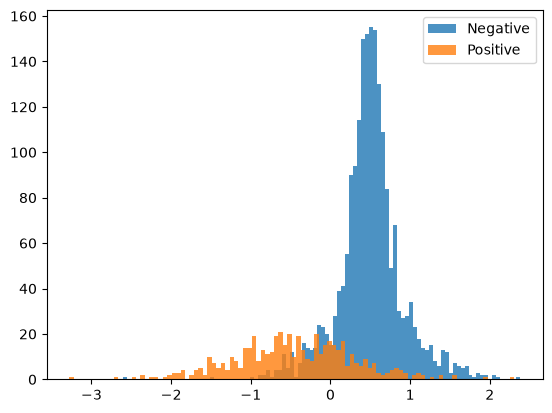

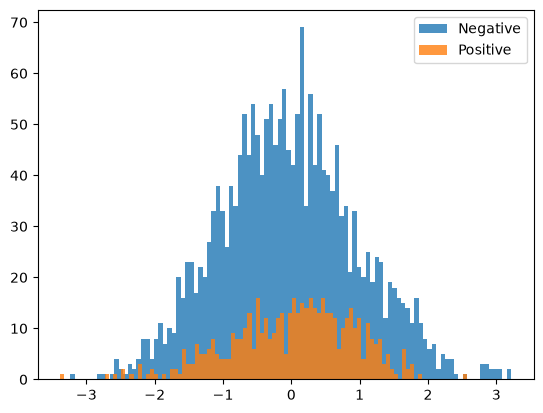

In [2]:
import matplotlib.pyplot as plt

# Dibujamos un histograma para cada una de las 2 características (features)
for i in range(2):
    plt.hist(data[:,i][labels == 1], bins=100, alpha=0.8, label = "Negative")
    plt.hist(data[:,i][labels == 0], bins=100, alpha=0.8, label = "Positive")
    plt.legend()
    plt.show()

### 8.2.1 Eligiendo un modelo: Redes Neuronales

Aunque un perceptrón por sí solo no es muy potente, podemos agrupar muchos de ellos para construir una **red neuronal**. En una red neuronal clásica o "feed-forward", las neuronas se organizan en **capas (layers)**:
1. **Capa de entrada (Input layer):** Recibe los datos originales.
2. **Capas ocultas o intermedias (Hidden layers):** Procesan la información a través de la red.
3. **Capa de salida (Output layer):** Emite la predicción o resultado final.

**¿Cómo fluye la información?**
Cada conexión entre neuronas de una capa y la siguiente tiene un **peso (weight)** numérico asignado, y cada neurona tiene un **sesgo (bias)** y una **función de activación**. 

Matemáticamente, el valor $a$ de una neurona $n$ en la capa $l$ se calcula sumando el valor de todas las neuronas de la capa anterior multiplicadas por sus respectivos pesos, sumándole el sesgo, y pasando el resultado por la función de activación $h$:

$$ a_{l,n} := h_{l,n} \left( b_{l,n} + \sum_k w_{k,l,n} \cdot a_{l-1,k} \right) $$

Durante el entrenamiento, el objetivo de la Inteligencia Artificial será ajustar todos esos pesos ($w$) y sesgos ($b$) para que la red acierte las clasificaciones.


#### Funciones de Activación

La función de activación es el "filtro" final que decide qué valor emite una neurona. Estas son las más utilizadas en Machine Learning:

1. **Sigmoide (Sigmoid):** Su fórmula es $S(x) = \frac{e^x}{e^x + 1}$. Es una curva suave que transforma cualquier número en un valor entre $0$ y $1$. Es ideal para la capa de salida en problemas de clasificación, ya que podemos interpretar su resultado como una probabilidad.
2. **ELU (Exponential Linear Unit):** Devuelve $x$ si el valor es positivo, y $e^x - 1$ si es negativo. Es suave y muy recomendable para las capas ocultas o intermedias de la red neuronal.
3. **ReLU (Rectified Linear Unit):** Su fórmula es $\max\{0, x\}$. Es decir, si el valor es negativo devuelve $0$, y si es positivo devuelve el mismo valor. Aunque no es una curva suave, es muy rápida de calcular y acelera el entrenamiento.


#### Diseñando nuestro clasificador binario

Dado que se ha demostrado que las redes neuronales son "aproximadores universales de funciones", son el modelo ideal para resolver nuestro problema de separar los datos en dos categorías. 

Para nuestro clasificador, diseñaremos una red neuronal con las siguientes características:
* **Capa de entrada:** Tendrá 2 neuronas (una para cada característica o *feature* de nuestros datos).
* **Capas ocultas:** Usaremos varias capas intermedias, todas ellas utilizando la función de activación **ELU**.
* **Capa de salida:** Tendrá una sola neurona con la función de activación **Sigmoide**. De esta forma, la red nos devolverá un valor continuo entre $0$ y $1$. 

Para tomar la decisión final, estableceremos un umbral en $0.5$: si la red devuelve un valor $\ge 0.5$, clasificaremos el dato como Positivo, y si es $< 0.5$, como Negativo.


### 8.2.2 Entendiendo las funciones de pérdida (Understanding loss functions)

Cuando entrenamos un modelo de aprendizaje supervisado, necesitamos una función matemática que evalúe cuánto se está equivocando nuestra red neuronal en sus predicciones.

Una opción muy popular es el **Error Cuadrático Medio (Mean Squared Error o MSE)**. Para calcular el error de entrenamiento, simplemente calculamos la diferencia entre lo que predice nuestro modelo y el valor real esperado, elevamos ese error al cuadrado, y calculamos el promedio para todo nuestro conjunto de datos de entrenamiento (haciendo lo mismo análogamente para los datos de validación). 

El MSE es una buena función de pérdida general, pero cuando se trata de entrenar **clasificadores binarios** (como el nuestro), existe un candidato matemático mucho mejor.


#### Entropía cruzada binaria (Binary cross-entropy)

Para nuestro problema de clasificación, utilizaremos la **entropía cruzada binaria**. Matemáticamente, para una etiqueta esperada $y$ y una predicción del modelo $M_\theta(x)$, se calcula así:

$$ H(\theta; x, y) = -y \log(M_\theta(x)) - (1 - y) \log(1 - M_\theta(x)) $$

Aunque la ecuación parezca intimidante, es una función de pérdida muy elegante y poderosa. Sus principales ventajas son:
1. **Es continua y derivable:** Dado que la salida de nuestro modelo (usando la función sigmoide) es continua y derivable respecto a sus parámetros, la función de pérdida también lo es. Esto es vital para el proceso de aprendizaje.
2. **Penaliza severamente los fallos:** Si la predicción de la red neuronal es idéntica a la etiqueta real ($M_\theta(x) = y$), el valor de esta función es exactamente $0$. Sin embargo, a medida que la predicción del modelo se acerca a la etiqueta equivocada, el valor de la pérdida crece exponencialmente y diverge hacia $\infty$.


### 8.2.3 Descenso de gradiente (Gradient descent)

Imagina que estás en la cima de una montaña, con los ojos vendados, y tu misión es llegar al fondo del valle. Aunque no puedas ver, puedes sentir la inclinación del terreno bajo tus pies y dar pequeños pasos en la dirección que desciende de forma más pronunciada. 

En el aprendizaje automático, hacemos exactamente esto para minimizar la función de pérdida $L$, la cual depende de los parámetros de nuestro modelo (los pesos y sesgos que elegimos) y es derivable matemáticamente. El equivalente matemático a buscar la dirección de "bajada más pronunciada" para una función $f$ en un punto $x$ viene dado por el vector gradiente negativo, es decir, $-\nabla f(x)$.

Para movernos hacia el mínimo del error, actualizamos los parámetros paso a paso en esa dirección. Al equivalente matemático del tamaño de cada "paso" que damos se le conoce como **tasa de aprendizaje (learning rate, comúnmente $\tau$)**. Si el paso es muy grande, podríamos saltarnos el valle; si es muy pequeño, tardaríamos una eternidad en llegar.


#### Retropropagación (Backpropagation)

Calcular a mano todas las derivadas parciales que forman el gradiente para una red neuronal compleja (que puede tener miles o millones de parámetros) sería una pesadilla computacional y muy propenso a errores. 

Afortunadamente, para solucionar esto existe un algoritmo analítico sumamente eficiente llamado **retropropagación (backpropagation)**. Este método rastrea hacia atrás cómo cada pequeño ajuste en los pesos de las distintas capas afectará a la pérdida final. Este algoritmo ha sido uno de los desarrollos fundamentales que han llevado al gran éxito actual del aprendizaje profundo (Deep Learning).


#### Variantes del Descenso de Gradiente

Cuando el conjunto de datos de entrenamiento es inmenso, calcular el gradiente evaluando absolutamente todos los datos a la vez ralentiza muchísimo el proceso. Para acelerar el entrenamiento, se juega con cómo agrupamos los datos:

* **Batch gradient descent (Descenso por lotes completos):** Se calcula el error usando todo el dataset a la vez para dar un solo paso.
* **Mini-batch gradient descent (Descenso por mini-lotes):** El conjunto de entrenamiento se divide en pequeños lotes de un tamaño fijo (por ejemplo, 32 o 64 ejemplos). El gradiente se calcula para cada lote y los parámetros se actualizan rápidamente de forma independiente. Hay que buscar un equilibrio: si el tamaño del lote es muy pequeño el entrenamiento será inestable, y si es muy grande será demasiado lento.
* **Stochastic gradient descent (Descenso estocástico):** Es el caso extremo en el que la red actualiza sus parámetros procesando y evaluando un solo dato de entrada a la vez.


### 8.2.4 Entrando en el (Tensor)Flow

Ya tenemos nuestro dataset generado, pero antes de entrenar, necesitamos dividirlo manualmente en los tres conjuntos que vimos en la teoría: entrenamiento, validación y prueba. 

Para no hacer el trabajo pesado, usaremos la función `train_test_split` de la librería `scikit-learn`, la cual mezcla y divide los datos aleatoriamente. La llamaremos dos veces: la primera para separar un 80% de entrenamiento y un 20% de prueba, y la segunda para dividir ese 20% restante a la mitad (dejando un 10% para validación y un 10% definitivo para prueba). 

**Un detalle clave:** Como nuestras categorías están desbalanceadas, usaremos el parámetro opcional `stratify`. Esto asegura que las proporciones originales de las clases se mantengan idénticas en todas las divisiones, evitando el riesgo de que la clase minoritaria desaparezca de alguno de los conjuntos de datos.


In [3]:
from sklearn.model_selection import train_test_split

# 1. Dividimos en entrenamiento (80%) y un bloque temporal de prueba (20%)
x_tr, x_test, y_tr, y_test = train_test_split(
    data, labels, shuffle = True, train_size = 0.8, stratify = labels)

# 2. Dividimos el bloque temporal a la mitad para obtener validación (10%) y prueba (10%)
x_val, x_test, y_val, y_test = train_test_split(
    x_test, y_test, shuffle = True, train_size = 0.5, stratify = y_test)

print(f"Datos de entrenamiento: {len(x_tr)}")
print(f"Datos de validación: {len(x_val)}")
print(f"Datos de prueba: {len(x_test)}")

Datos de entrenamiento: 2000
Datos de validación: 250
Datos de prueba: 250


#### Construyendo el modelo en TensorFlow

Para nuestro problema de clasificación binaria, vamos a crear una red neuronal con los siguientes componentes:
* **Capa de entrada:** 2 neuronas (una para cada característica de nuestros datos).
* **Capas ocultas:** Tres capas intermedias con la función de activación **ELU**, que tendrán 8, 16 y 8 neuronas, respectivamente (fíjate cómo la red crece y luego se encoge).
* **Capa de salida:** 1 sola neurona con función de activación **sigmoide**, para que nos devuelva una probabilidad entre 0 y 1.

Construiremos esto usando un modelo secuencial (`Sequential`) de la API Keras incluida en TensorFlow. Una vez definida la arquitectura, "compilaremos" el modelo pasándole las herramientas matemáticas que va a usar: nuestro optimizador (Adam) y nuestra función de pérdida (Entropía Cruzada Binaria).


In [4]:

import tensorflow as tf
from tensorflow import keras

# Fijamos la misma semilla que antes para que la inicialización sea reproducible
tf.random.set_seed(seed)

# Definimos la arquitectura de la red neuronal capa por capa
model = keras.Sequential([
    keras.layers.Input(shape = (2,)),
    keras.layers.Dense(8, activation = "elu"),
    keras.layers.Dense(16, activation = "elu"),
    keras.layers.Dense(8, activation = "elu"),
    keras.layers.Dense(1, activation = "sigmoid"),
])

# Elegimos el optimizador (Adam) y la función de pérdida (Entropía cruzada binaria)
opt = keras.optimizers.Adam()
lossf = keras.losses.BinaryCrossentropy()

# Compilamos el modelo para dejarlo listo para el entrenamiento
model.compile(optimizer = opt, loss = lossf)

# Si quieres ver un resumen visual de la red y sus parámetros, descomenta la siguiente línea:
print(model.summary())
print("Modelo compilado con éxito.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313 (1.22 KB)

 Trainable params: 313 (1.22 KB)

 Non-trainable params: 0 (0.00 B)

None
Modelo compilado con éxito.


### 8.2.5 Entrenando el modelo (Training the model)

Para entrenar nuestro modelo en TensorFlow, simplemente tenemos que llamar al método `fit`. Este método necesita varios argumentos clave:

* **Datos y etiquetas:** Los arrays con nuestras características (`x_tr`) y las respuestas correctas (`y_tr`).
* **batch_size (Tamaño del lote):** Si queremos usar descenso de gradiente por mini-lotes, le indicamos el tamaño. Si queremos usar todo el dataset de golpe (batch gradient descent), lo fijamos en `None`.
* **epochs (Épocas):** El número de ciclos de optimización completos que el algoritmo dará sobre los datos. Para empezar, usaremos `8` épocas.
* **validation_data:** Le pasamos nuestro conjunto de validación (`x_val`, `y_val`) para que, al final de cada época, el modelo nos muestre cómo de bien lo está haciendo con datos que no está usando para entrenar.


In [5]:
# Entrenamos el modelo y guardamos el progreso en la variable 'history'
history = model.fit(x_tr, y_tr,
                    validation_data = (x_val, y_val), 
                    epochs = 8,
                    batch_size = None)

Epoch 1/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4984 - val_loss: 0.3436
Epoch 2/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3223 - val_loss: 0.2810
Epoch 3/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2992 - val_loss: 0.2734
Epoch 4/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2933 - val_loss: 0.2709
Epoch 5/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2884 - val_loss: 0.2683
Epoch 6/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2832 - val_loss: 0.2651
Epoch 7/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2777 - val_loss: 0.2618
Epoch 8/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2720 - val_loss: 0.2588


#### Parada temprana y Predicciones

Fijar el número de épocas a mano no siempre es la mejor estrategia. Lo ideal es decirle al modelo que entrene hasta que deje de mejorar, para evitar hacer cálculos innecesarios o caer en *overfitting*. Esto se conoce como **Parada Temprana (Early Stopping)** y en TensorFlow se puede configurar para que detenga el entrenamiento si la pérdida de validación (`val_loss`) no mejora tras un número determinado de épocas.

Una vez entrenado, queremos que el modelo procese datos nuevos. Para ello usamos el método `predict` pasándole nuestro conjunto de prueba (`x_test`). Como nuestra capa de salida usa una función de activación sigmoide, el modelo nos devolverá valores continuos entre $0$ y $1$ (probabilidades). Para convertirlos en etiquetas discretas (categoría $0$ o $1$), simplemente establecemos un umbral en $0.5$.


In [6]:
from sklearn.metrics import accuracy_score

# Hacemos las predicciones con el conjunto de test aislado
# Aplicamos el umbral de 0.5 para convertir las probabilidades en etiquetas enteras (0 o 1)
result = (model.predict(x_test) >= 0.5).astype(int)

# Calculamos la exactitud comparando las predicciones con las respuestas reales
acc = accuracy_score(result, y_test)
print(f"\nExactitud (accuracy) del modelo: {acc * 100}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Exactitud (accuracy) del modelo: 87.2%


### 8.3 Modelos cuántico-clásicos (Quantum-classical models)

El Aprendizaje Automático Cuántico (QML) es un campo muy nuevo que abarca muchas ideas y aplicaciones diferentes. Para entender bien qué estamos haciendo, podemos utilizar la famosa clasificación propuesta por Maria Schuld y Francesco Petruccione, que divide el QML en cuatro grandes familias dependiendo de si los datos a procesar y el algoritmo que los procesa son clásicos (C) o cuánticos (Q):

1. **CC (Datos Clásicos, Algoritmo Clásico):** Técnicas de machine learning clásico que simplemente se inspiran en ideas de la computación cuántica, pero no usan ordenadores cuánticos reales.
2. **QC (Datos Cuánticos, Algoritmo Clásico):** Consiste en utilizar algoritmos de machine learning clásico de toda la vida para analizar datos provenientes de sistemas cuánticos (por ejemplo, para caracterizar o calibrar dispositivos cuánticos).
3. **CQ (Datos Clásicos, Algoritmo Cuántico):** Uso de algoritmos cuánticos para procesar y aprender de datos clásicos tradicionales (como bases de datos, imágenes o texto).
4. **QQ (Datos Cuánticos, Algoritmo Cuántico):** Es el aprendizaje automático cuántico "puro", donde un algoritmo cuántico procesa estados cuánticos directamente. Aunque es prometedor, aún es un área muy teórica debido a que no tenemos formas eficientes de almacenar grandes cantidades de datos cuánticos (como la qRAM).


#### Nuestra ruta: Aprendizaje CQ y Modelos a estudiar

En este libro nos vamos a centrar exclusivamente en el **aprendizaje automático CQ**: utilizaremos modelos que corren en ordenadores cuánticos reales (o simuladores) para analizar bases de datos clásicas y en general, emplearemos técnicas de optimización clásicas para entrenarlos. 

En los próximos capítulos programaremos desde cero los siguientes modelos:

* **Máquinas de Vectores de Soporte Cuánticas (QSVMs - Capítulo 9):** Usaremos el famoso "truco del kernel" con circuitos cuánticos para mapear datos a un espacio de estados cuánticos y poder clasificarlos.
* **Redes Neuronales Cuánticas (QNNs - Capítulo 10):** Construiremos un modelo completamente cuántico inspirado en el funcionamiento de las redes neuronales clásicas.
* **Redes Híbridas (Capítulo 11):** Aprenderemos a fusionar lo mejor de ambos mundos, combinando capas de redes neuronales clásicas (usando PyTorch y TensorFlow) con capas de redes neuronales cuánticas.
* **Redes Generativas Antagónicas Cuánticas (QGANs - Capítulo 12):** Daremos el salto al aprendizaje no supervisado y usaremos circuitos cuánticos para generar datos completamente nuevos que imiten a un conjunto de entrenamiento.


## Capítulo 9: Máquinas de Vectores de Soporte Cuánticas (QSVM)

### 9.1 Máquinas de Vectores de Soporte (SVM)
#### 9.1.1 El clasificador más simple que puedas imaginar

Antes de aplicar la computación cuántica, consideremos el problema de clasificación binaria más ingenuo y sencillo posible. 

Si tuviéramos datos repartidos en una simple línea recta (1 dimensión), la forma más natural de clasificarlos sería **elegir un punto** $a$ que divida la línea en dos: los números menores que $a$ pertenecerían a una categoría, y los mayores que $a$ a la otra.

Si subimos de nivel y pasamos a un plano (2 dimensiones, $\mathbb{R}^2$), un solo punto ya no es suficiente para dividir el espacio. En su lugar, utilizaríamos una **línea recta** para separar el plano perfectamente en dos categorías. Si siguiéramos generalizando esto a espacios de $n$ dimensiones ($\mathbb{R}^n$), utilizaríamos el equivalente matemático de una línea para múltiples dimensiones, que recibe el nombre de **hiperplano**.


#### La frontera de decisión y las matemáticas de la SVM

Una **Máquina de Vectores de Soporte (SVM)** es, en su esencia, un modelo geométrico que toma datos de entrada en un espacio de $n$ dimensiones y los clasifica dependiendo de en qué lado de un hiperplano se encuentren.

Cualquier hiperplano puede caracterizarse matemáticamente utilizando solo dos parámetros ajustables (que serán los que nuestro modelo tendrá que aprender):
1. Un vector normal $\vec{w}$, que define la dirección perpendicular al plano.
2. Un escalar $b$ (sesgo o bias).

El hiperplano estará formado exactamente por todos los puntos $\vec{x}$ que cumplan la ecuación geométrica $\vec{w} \cdot \vec{x} + b = 0$. 

Gracias a esta formulación, una vez que nuestro modelo SVM ha trazado su hiperplano de separación, clasificar un nuevo punto de datos $\vec{x}$ es una tarea trivial: **solo tenemos que calcular el signo** de $\vec{w} \cdot \vec{x} + b$. Dependiendo de si el valor es positivo o negativo, el punto estará a un lado u otro del hiperplano, dictando así la categoría final que predice el modelo.



### 9.1.2 Cómo entrenar Máquinas de Vectores de Soporte: el caso del margen duro

Si tenemos un conjunto de datos de entrenamiento que puede separarse perfectamente en dos categorías, existen infinitos hiperplanos que logran esta separación. Sin embargo, si trazamos un hiperplano que pase demasiado cerca de los puntos de entrenamiento, corremos el riesgo de que nuevos datos (que sigan una distribución similar pero con ligeras variaciones) crucen la línea y sean clasificados incorrectamente.

Por ello, el objetivo al entrenar una SVM es encontrar el hiperplano separador que esté **lo más lejos posible** de los puntos de entrenamiento. A la distancia entre los dos hiperplanos paralelos que encapsulan la frontera de decisión se le conoce como **margen**, y nuestro objetivo es maximizarlo.


#### Las matemáticas del Margen

Dado un hiperplano central $H$ definido por $\vec{w} \cdot \vec{x} + b = 0$, podemos trazar dos hiperplanos paralelos a él que pasen justo por encima de los puntos de datos más cercanos de cada categoría. Ajustando los parámetros, podemos hacer que estos dos hiperplanos límite tengan una ecuación matemática muy elegante:
$$ \vec{w} \cdot \vec{x} + b = 1 \quad \text{y} \quad \vec{w} \cdot \vec{x} + b = -1 $$

La geometría nos dice que la distancia total entre estos dos hiperplanos paralelos (el margen) es exactamente $2/\|\vec{w}\|$. Por lo tanto, el problema de maximizar el margen es matemáticamente equivalente a minimizar la norma del vector $\vec{w}$.


#### El problema de optimización (Hard-Margin)

Para asegurarnos de que el hiperplano clasifica correctamente todos los datos y ningún punto invade el margen, exigimos que para cada punto de entrenamiento $\vec{x}_j$ con etiqueta $y_j \in \{1, -1\}$, se cumpla la restricción $y_j(\vec{w} \cdot \vec{x}_j + b) \ge 1$.

Juntando esto con nuestro objetivo de maximizar el margen, el entrenamiento de la SVM se convierte en el siguiente problema de optimización:

* **Minimizar:** $\frac{1}{2}\|\vec{w}\|^2$
* **Sujeto a las restricciones:** $y_j(\vec{w} \cdot \vec{x}_j + b) \ge 1$

A esto se le conoce como **entrenamiento de margen duro (hard-margin)**, porque somos estrictos: no permitimos que absolutamente ningún elemento de entrenamiento sea clasificado incorrectamente ni caiga dentro del margen. El factor $\frac{1}{2}$ y elevar al cuadrado se añaden simplemente por conveniencia técnica a la hora de derivar.


### 9.1.3 Entrenamiento de margen blando (Soft-margin training)

El entrenamiento de margen duro requiere que los datos puedan separarse perfectamente con un hiperplano, lo cual suele ser imposible si los datos están muy mezclados. Para solucionar esto, el **margen blando** introduce unos parámetros ajustables de holgura o "tolerancia", denotados como $\xi_j \ge 0$, que darán flexibilidad a nuestras restricciones matemáticas.

En lugar de exigir la restricción estricta del margen duro, usaremos la siguiente fórmula:
$$ y_j(\vec{w} \cdot \vec{x}_j + b) \ge 1 - \xi_j $$


De esta forma, cuando $\xi_j > 0$, estamos permitiendo que el punto de datos $\vec{x}_j$ caiga dentro del margen o incluso en el lado equivocado del hiperplano separador. Cuanto mayor sea el valor de $\xi_j$, más alejado estará el punto en el lado incorrecto de la frontera.



#### El problema de optimización y el hiperparámetro C

Por supuesto, no queremos que nuestro modelo cometa errores gratis o clasifique todo mal. Para evitarlo, añadimos la suma de todas estas variables de holgura a la función que queremos minimizar, multiplicadas por una constante $C > 0$. El nuevo problema de optimización para entrenar nuestra SVM queda así:

*   **Minimizar:** $\frac{1}{2}\|\vec{w}\|^2 + C \sum_j \xi_j$
*   **Sujeto a:** $y_j(\vec{w} \cdot \vec{x}_j + b) \ge 1 - \xi_j \quad \text{y} \quad \xi_j \ge 0$

La constante $C$ es un **hiperparámetro** vital que nosotros debemos elegir antes de entrenar:
* **Si $C$ es muy grande:** Seremos muy poco tolerantes a los fallos en el conjunto de entrenamiento. El modelo intentará encajar todo perfectamente, acercándose al comportamiento del margen duro y aumentando el riesgo de sufrir *overfitting*.
* **Si $C$ es pequeño:** Seremos más tolerantes, permitiendo que algunos puntos caigan en el lado equivocado a cambio de encontrar una frontera más general que funcione mejor con datos nuevos.


#### La formulación Dual

Resolver el problema anterior directamente puede ser complicado. Sin embargo, matemáticamente se puede transformar en lo que se conoce como el **dual lagrangiano** del problema de optimización, que en la práctica suele ser mucho más fácil de resolver computacionalmente:

*   **Maximizar:** $\sum_j \alpha_j - \frac{1}{2} \sum_{j,k} y_j y_k \alpha_j \alpha_k (\vec{x}_j \cdot \vec{x}_k)$
*   **Sujeto a:** $0 \le \alpha_j \le C \quad \text{y} \quad \sum_j \alpha_j y_j = 0$

Esta nueva formulación introduce unos parámetros optimizables $\alpha_j$, pero lo más revelador e importante es que los datos originales $\vec{x}$ **solo aparecen dentro de un producto escalar** $(\vec{x}_j \cdot \vec{x}_k)$. ¡Esta propiedad matemática será la clave fundamental que nos permitirá introducir más adelante la magia de la computación cuántica!


## 9.2 Dando el salto cuántico (Going quantum)

### 9.2.1 La idea general detrás de las QSVM

Como hemos visto, el truco del kernel toma nuestros datos y los lleva a un espacio de dimensiones superiores (espacio de características) con la esperanza de que allí sí sean separables linealmente. Generalmente, este espacio es simplemente un espacio euclidiano más grande. Pero, ¿y si consideramos otras opciones? ¿Qué tal... **el espacio de los estados cuánticos**?.

Una Máquina de Vectores de Soporte Cuántica (QSVM) funciona exactamente igual que una SVM clásica que utiliza el truco del kernel, con una única pero crucial diferencia: **el espacio de características es el espacio de estados de un sistema cuántico, y el mapa de características (la función que transforma los datos) es un circuito cuántico**.


#### Computando el Kernel Cuántico

Para entrenar nuestra QSVM o clasificar nuevos datos, no necesitamos conocer las coordenadas exactas de nuestros datos en el inmenso espacio cuántico; solo necesitamos saber calcular el producto escalar entre ellos (el valor del kernel). 

Si tomamos un mapa de características que nos devuelve un circuito cuántico $\Phi(x)$ para cualquier entrada $x$, ¿cómo calculamos el kernel entre dos puntos $a$ y $b$? 
La respuesta es brillante: preparamos el estado aplicando primero el circuito del punto $b$, es decir $\Phi(b)$, y a continuación aplicamos el **inverso** del circuito del punto $a$, es decir $\Phi^\dagger(a)$. El resultado de nuestro kernel será, simplemente, **la probabilidad de medir cero en todos los qubits** al final del circuito.


#### Inversión de circuitos y validez matemática

Dado que los circuitos cuánticos siempre están representados por operaciones unitarias (y por tanto, reversibles), calcular el circuito inverso $\Phi^\dagger$ es muy sencillo. Como $\Phi$ está compuesto por una serie de puertas cuánticas, todo lo que tenemos que hacer es **aplicar las puertas del circuito original de derecha a izquierda (en orden inverso) e invertir cada una de ellas**.

Todos los kernels cuánticos definidos de esta manera cumplen a la perfección con las estrictas condiciones matemáticas necesarias para ser considerados funciones kernel válidas (por ejemplo, la propiedad de ser simétricos).


### 9.2.2 Mapas de características (Feature maps)

Un mapa de características se define habitualmente mediante un circuito parametrizado $\Phi(x)$ que depende exclusivamente de los datos originales. Veamos algunos de los mapas de características más populares:

#### 1. Codificación de ángulo (Angle encoding)

Este es un mapa de características simple pero poderoso. En un circuito de $n$ qubits, puede tomar hasta $n$ entradas numéricas $x_1, \dots, x_n$. Su funcionamiento consiste en aplicar una puerta de rotación en cada qubit $j$ usando el valor $x_j$ de nuestro dato como el ángulo de rotación.

En esta codificación somos libres de usar cualquier puerta de rotación ($R_X$, $R_Y$, o $R_Z$). Sin embargo, si usamos puertas $R_Z$ partiendo del estado inicial $|0\rangle$, la rotación no tendría efecto observable. Por eso, cuando se usan puertas $R_Z$, es habitual precederlas aplicando puertas Hadamard (H) en cada qubit. Al usar este método, es recomendable normalizar las variables de entrada a un rango como $[-\pi, \pi]$ o $[0, 2\pi]$ para aprovechar todo el espacio disponible.


#### 2. Codificación de amplitud (Amplitude encoding)

La codificación de ángulo usa $n$ qubits para $n$ datos. Sin embargo, la codificación de amplitud da un salto gigante: nos permite tomar hasta **$2^n$ datos de entrada usando solo $n$ qubits**. Esto nos permitirá entrenar QSVMs en conjuntos de datos con un gran número de variables.

Si le damos a este mapa una entrada clásica $x_0, \dots, x_{2^n-1}$, el circuito simplemente preparará un estado cuántico en el que las amplitudes de los $2^n$ estados de la base computacional corresponderán exactamente a esos $2^n$ valores de nuestros datos. Para que este método funcione, la única condición estricta es que el array de datos de entrada debe estar normalizado para que la suma de sus componentes al cuadrado sea exactamente $1$ (cumpliendo así con la regla de normalización de las amplitudes cuánticas).


#### 3. Mapa de características ZZ (ZZ feature map)

Este mapa de características viene implementado de forma nativa en Qiskit y puede tomar $n$ entradas en $n$ qubits, al igual que la codificación de ángulo. Su circuito parametrizado se construye siguiendo estos pasos precisos:

1. Se aplica una puerta Hadamard en cada qubit.
2. Se aplica a cada qubit $j$ una rotación $R_Z(2x_j)$.
3. Para cada par de qubits interconectados $j$ y $k$ (con $j < k$), se aplica la parte entrelazada:
   - Una puerta CNOT controlada por el qubit $j$ apuntando al qubit $k$.
   - Una rotación $R_Z(2(\pi - x_j)(\pi - x_k))$ aplicada sobre el qubit $k$.
   - Otra puerta CNOT idéntica a la primera.

Al igual que en los demás mapas, la normalización juega un papel vital. Para garantizar un buen equilibrio y utilizar la mayor región posible del espacio de características cuántico, las variables suelen normalizarse a rangos como $$ o $$.


## 9.3 Máquinas de Vectores de Soporte Cuánticas en PennyLane
### 9.3.1 Preparando el terreno para entrenar una QSVM

Para entrenar nuestra QSVM necesitamos datos. Vamos a utilizar el famoso "Wine recognition dataset" (conjunto de datos de reconocimiento de vino) incluido en la librería `scikit-learn`. Este conjunto de datos tiene 13 variables numéricas (como intensidad del color, concentración de alcohol, etc.) y clasifica los vinos en 3 categorías.

Como queremos resolver un problema de **clasificación binaria**, simplemente tomaremos las dos primeras categorías (los primeros 59 y 71 elementos del conjunto, respectivamente) e ignoraremos la tercera. 

*(Nota: Este es un problema muy sencillo desde el punto de vista del Machine Learning, por lo que no veremos una "ventaja cuántica" real al usar QML, pero es un ejemplo perfecto para aprender a programar el modelo).*


In [7]:
import numpy as np
from sklearn.datasets import load_wine

# Fijamos una semilla para que los resultados sean reproducibles
seed = 1234
np.random.seed(seed)

# Cargamos el dataset de vinos
x, y = load_wine(return_X_y = True)

# Filtramos para quedarnos solo con las dos primeras clases (59 de la clase 0 y 71 de la clase 1)
x = x[:59+71]
y = y[:59+71]

print(f"Datos cargados exitosamente. Tamaño del dataset: {len(x)} elementos.")


Datos cargados exitosamente. Tamaño del dataset: 130 elementos.


#### División y Normalización de los datos

Al igual que hicimos con los modelos clásicos, necesitamos dividir nuestro conjunto de datos en un bloque de entrenamiento (90%) y uno de prueba (10%). En este caso específico no usaremos conjunto de validación.

Además, como la mayoría de los mapas de características cuánticos requieren que los datos estén normalizados, usaremos la herramienta `MaxAbsScaler` para escalar todas las variables linealmente, de forma que su valor absoluto máximo sea 1. Es fundamental recordar que el escalador debe "aprender" las proporciones (`fit_transform`) **solo** con los datos de entrenamiento, y luego aplicar esa misma transformación (`transform`) a los datos de prueba.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler

# Dividimos en entrenamiento (90%) y prueba (10%)
x_tr, x_test, y_tr, y_test = train_test_split(x, y, train_size = 0.9)

# Normalizamos los datos de entrenamiento
scaler = MaxAbsScaler()
x_tr = scaler.fit_transform(x_tr)

# Aplicamos la misma transformación a los datos de prueba
x_test = scaler.transform(x_test)

# Recortamos los valores por si algún dato de prueba se sale del rango debido a valores atípicos
x_test = np.clip(x_test, 0, 1)

print("Datos divididos y normalizados correctamente.")

Datos divididos y normalizados correctamente.


### 9.3.2 La primera cita entre PennyLane y scikit-learn

Como hemos dicho muchas veces, una QSVM es como una SVM normal, pero con un kernel cuántico. Nuestro dataset de vinos tiene 13 variables, por lo que usar la codificación de ángulo o el mapa de características ZZ nos obligaría a usar 13 qubits, lo cual puede ser demasiado para simularlo en ordenadores convencionales. Por ello, recurriremos a la codificación de amplitud (*Amplitude encoding*), que nos permite incrustar las 13 variables usando tan solo 4 qubits (ya que $2^4 = 16 \ge 13$).

En el siguiente código, definimos un circuito cuántico que aplica la codificación de amplitud para el dato de entrada `a`, y luego la inversa (adjunta) de la codificación para el dato `b`. Rellenaremos los 3 espacios sobrantes hasta llegar a 16 con ceros (`pad_with=0.`) y nos aseguraremos de que los datos se normalicen internamente (`normalize=True`). Finalmente, el primer elemento del array devuelto (es decir, la probabilidad de medir el valor cero en todos los qubits) será la salida de nuestro kernel cuántico.


In [9]:
import pennylane as qml
nqubits = 4
dev = qml.device("default.qubit", wires=nqubits)

@qml.qnode(dev)
def kernel_circ(a, b):
    qml.AmplitudeEmbedding(a, wires=range(nqubits),
                           pad_with=0., normalize=True)
    qml.adjoint(qml.AmplitudeEmbedding(b, wires=range(nqubits),
                                       pad_with=0., normalize=True))
    return qml.probs(wires = range(nqubits))

# Envolvemos el cálculo para procesar dos matrices de datos A y B
def qkernel(A, B):
    return np.array([[kernel_circ(a, b)[0] for b in B] for a in A])


#### Entrenando la SVM con nuestro Kernel Cuántico

Nuestro siguiente paso será usar este kernel cuántico en una SVM. Nuestra vieja amiga, la librería `scikit-learn`, tiene su propia implementación de máquinas de vectores de soporte (la clase `SVC`) y está programada de tal forma que acepta el uso de kernels personalizados. 

Para usarlo, solo estamos obligados a proporcionarle una función de kernel que acepte dos arrays (A y B) y devuelva la matriz calculada, que es exactamente lo que hace nuestra función `qkernel`. Al entrenar el modelo con el método `fit`, calculará las distancias en el espacio cuántico para todos los datos de entrenamiento y, finalmente, evaluaremos la exactitud (*accuracy*) con el conjunto de prueba.


In [10]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Entrenamos el modelo usando nuestro kernel cuántico personalizado
svm = SVC(kernel = qkernel).fit(x_tr, y_tr)

# Comprobamos la exactitud (accuracy) con los datos de prueba
print(accuracy_score(svm.predict(x_test), y_test))

0.9230769230769231


### 9.3.3 Reduciendo la dimensionalidad de un dataset

Hasta ahora hemos visto cómo la codificación de amplitud nos permite usar las 13 variables de nuestro dataset con solo 4 qubits. Sin embargo, en algunos problemas puede ser mejor reducir el número de variables (tratando de minimizar la pérdida de información) para poder usar otros mapas de características cuánticos.

Para ilustrar este enfoque, reduciremos nuestro dataset de 13 a 8 variables usando la técnica de **Análisis de Componentes Principales (PCA)**. A grandes rasgos, el PCA encuentra las "direcciones principales" (las líneas ortogonales que mejor se ajustan a los datos) en el espacio original para proyectar los datos y reducir así sus dimensiones.

In [11]:
from sklearn.decomposition import PCA

# Reducimos la dimensionalidad a 8 variables usando PCA
pca = PCA(n_components = 8)
xs_tr = pca.fit_transform(x_tr)
xs_test = pca.transform(x_test)

# Como el PCA ha cambiado los rangos, volvemos a normalizar los datos reducidos
scaler = MaxAbsScaler()
xs_tr = scaler.fit_transform(xs_tr)
xs_test = scaler.transform(xs_test)
xs_test = np.clip(xs_test, -1, 1)

print("Datos reducidos y normalizados correctamente.")

Datos reducidos y normalizados correctamente.


#### Entrenando con el nuevo conjunto de datos y Codificación de Ángulo

Ahora que tenemos solo 8 variables, podemos probar a entrenar nuestra QSVM utilizando la **Codificación de Ángulo (Angle encoding)**. 

Para ello usaremos 8 qubits y la plantilla `AngleEmbedding` integrada en PennyLane (seguida de la versión inversa o adjunta para el segundo dato). Finalmente, usaremos este nuevo kernel para volver a entrenar el modelo SVM y evaluar si nuestra precisión mejora o empeora.


In [12]:
nqubits = 8
dev = qml.device("default.qubit", wires=nqubits)

@qml.qnode(dev)
def kernel_circ(a, b):
    qml.AngleEmbedding(a, wires=range(nqubits))
    qml.adjoint(qml.AngleEmbedding(b, wires=range(nqubits)))
    return qml.probs(wires = range(nqubits))

# Reutilizamos nuestra función qkernel anterior pero internamente llamará al nuevo kernel_circ
svm = SVC(kernel = qkernel).fit(xs_tr, y_tr)

print("Accuracy con PCA y Angle Encoding:", accuracy_score(svm.predict(xs_test), y_test))


Accuracy con PCA y Angle Encoding: 1.0


### 9.3.4 Implementando y usando mapas de características personalizados

PennyLane viene con una amplia selección de mapas de características integrados que podemos usar directamente. Sin embargo, es posible que en algunos problemas queramos definir nuestra propia estructura de codificación cuántica. 

En este apartado, vamos a entrenar una QSVM sobre el conjunto de datos reducido que creamos con PCA, pero esta vez utilizando nuestra propia implementación en código puro del **ZZ feature map**. Para programarlo, simplemente traduciremos a puertas lógicas de PennyLane los pasos matemáticos que definen a este mapa (aplicar puertas Hadamard, rotaciones $R_Z$ individuales y finalmente rotaciones $R_Z$ entrelazadas controladas mediante puertas CZ).


In [13]:
from itertools import combinations

def ZZFeatureMap(nqubits, data):
    # Número de variables que cargaremos:
    # podría ser menor que el número de qubits.
    nload = min(len(data), nqubits)
    
    for i in range(nload):
        qml.Hadamard(i)
        qml.RZ(2.0 * data[i], wires = i)
        
    for pair in list(combinations(range(nload), 2)):
        q0 = pair[0]
        q1 = pair[1]
        qml.CNOT(wires = [q0, q1])
        qml.RZ(2.0 * (np.pi - data[q0]) * (np.pi - data[q1]), wires = q1)
        qml.CNOT(wires = [q0, q1])

#### Entrenando la QSVM con nuestra función personalizada

Una vez que hemos programado la función para el *ZZ feature map*, podemos usarla para construir nuestro circuito del kernel cuántico y entrenar el modelo de la misma forma que hemos hecho antes.

**¡Un detalle crucial!** Fíjate en el código a continuación cómo la función `qml.adjoint` (que calcula el circuito inverso) se aplica directamente sobre el *nombre* de la función `ZZFeatureMap` en sí, y **no** sobre su salida. 


In [14]:
nqubits = 4
dev = qml.device("default.qubit", wires = nqubits)

@qml.qnode(dev)
def kernel_circ(a, b):
    # 1. Aplicamos el feature map al dato 'a'
    ZZFeatureMap(nqubits, a)
    # 2. Aplicamos la inversa del feature map al dato 'b'
    qml.adjoint(ZZFeatureMap)(nqubits, b)
    
    return qml.probs(wires = range(nqubits))

# Entrenamos usando de nuevo la función qkernel que habíamos definido en apartados anteriores
svm = SVC(kernel=qkernel).fit(xs_tr, y_tr)

print("Accuracy con nuestro ZZ Feature Map:", accuracy_score(svm.predict(xs_test), y_test))


Accuracy con nuestro ZZ Feature Map: 1.0


## 9.4 Máquinas de Vectores de Soporte Cuánticas en Qiskit

En cierto modo, Qiskit puede resultar más sencillo de utilizar que PennyLane para este propósito, y además nos permitirá entrenar y ejecutar nuestros modelos QSVM directamente en los ordenadores cuánticos reales de IBM Quantum. Pero por ahora, empezaremos ejecutando nuestra QSVM en el simulador local Qiskit Aer.

### 9.4.1 QSVMs en Qiskit Aer

A diferencia de PennyLane, donde teníamos que programar "manualmente" la función del kernel para pasarla a `scikit-learn`, Qiskit simplifica mucho este proceso. Todo lo que necesitamos hacer es instanciar un objeto `QuantumKernel`. Este objeto requiere un *backend* (donde se ejecutará) y un mapa de características (*feature map*). Por defecto utiliza el mapa ZZ de dos qubits, pero nosotros usaremos la versión de 8 qubits importada directamente desde la librería de circuitos de Qiskit.


In [15]:
from qiskit import *
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# Instanciamos el mapa de características ZZ para 8 qubits
zzfm = zz_feature_map(8)

# Configuramos el kernel cuántico
qkernel = FidelityQuantumKernel(feature_map = zzfm)

#### Entrenando el modelo QSVC

Una vez que tenemos nuestro kernel cuántico, podemos entrenar el modelo. Qiskit incluye su propia extensión de la clase `SVC` de `scikit-learn`, llamada `QSVC`. Funciona exactamente igual que la original, pero acepta directamente nuestro objeto `QuantumKernel` a través del parámetro `quantum_kernel`.

Para el entrenamiento, reutilizaremos el conjunto de datos reducido a 8 variables (`xs_tr` y `xs_test`) que preparamos en apartados anteriores con PCA.


In [16]:
from qiskit_machine_learning.algorithms import QSVC
from sklearn.metrics import accuracy_score

# Creamos el clasificador de vectores de soporte cuántico
qsvm = QSVC(quantum_kernel = qkernel)

# Entrenamos el modelo
qsvm.fit(xs_tr[:40], y_tr[:40])  # Subset de 40 muestras para simulación rápida

# Comprobamos la exactitud con el conjunto de prueba
print("Accuracy en Qiskit Aer:", accuracy_score(qsvm.predict(xs_test), y_test))


Accuracy en Qiskit Aer: 0.5384615384615384


## Capítulo 10: Redes Neuronales Cuánticas (QNN)
### 10.1 Construyendo y entrenando una red neuronal cuántica
#### 10.1.1 De las redes neuronales clásicas a las cuánticas

Podemos pensar en el funcionamiento de una red neuronal clásica como un proceso de tres etapas: preparación de los datos (capa de entrada), procesamiento (capas ocultas con pesos y sesgos) y salida (capa final). Las Redes Neuronales Cuánticas (QNN, por sus siglas en inglés) se inspiran directamente en esta estructura.

Una QNN opera mediante las siguientes etapas análogas:
1. **Preparación de los datos:** Tomamos una entrada clásica $\vec{x}$ y la mapeamos a un estado cuántico usando un mapa de características (feature map) $F$.
2. **Procesamiento de los datos:** El estado cuántico pasa a través de un circuito parametrizado $V(\vec{\theta})$ que depende de unos parámetros optimizables $\vec{\theta}$. A este circuito estructurado en capas se le conoce como **forma variacional (variational form)**.
3. **Salida de los datos:** La salida del modelo (el resultado final) se obtiene realizando una operación de medición sobre el estado cuántico resultante.



#### 10.1.2 Formas variacionales (Variational forms)

Para imitar a las redes clásicas, las formas variacionales de las QNN suelen tener una "estructura de capas". Una forma variacional con $k$ capas utiliza una secuencia de circuitos variacionales $G_j$ (que dependen de parámetros $\theta_j$), separados por circuitos $U_{ent}$ que no dependen de ningún parámetro y cuya única función es crear entrelazamiento entre los qubits.

Aunque se puede diseñar cualquier circuito, nos centraremos en tres formas variacionales muy comunes:
* **Two-local:** Consta de $k$ repeticiones (lo que en la práctica resulta en $k+1$ capas) y utiliza rotaciones $R_Y$ en cada qubit, seguidas de una cascada de puertas CNOT para generar entrelazamiento. Utiliza exactamente la misma estructura de circuito que el mapa de características de codificación por ángulo.
* **Tree tensor:** Se aplica sobre $n=2^k$ qubits y en cada capa se reduce a la mitad el número de parámetros respecto a la anterior. Utiliza rotaciones $R_Y$ y puertas CNOT dispuestas simulando una estructura de árbol.
* **Capas fuertemente entrelazadas (Strongly entangling layers):** En cada capa, aplica tres rotaciones consecutivas ($R_Z$, $R_Y$ y $R_Z$) a cada qubit, seguidas de operaciones CNOT cuyos objetivos dependen de un parámetro de "rango" $r_l$ propio de cada capa.


#### 10.1.3 Unas palabras sobre las mediciones (A word about measurements)

Como vimos al estudiar el algoritmo VQE, cualquier observable físico puede representarse matemáticamente mediante una matriz Hermitiana. Al medir el estado final de nuestra red neuronal cuántica, solemos utilizar dos observables muy comunes para evaluar un solo qubit:

1. **El observable $M$:** Cuya matriz es $\begin{pmatrix} 1 & 0 \\ 0 & 0 \end{pmatrix}$. Este operador asocia el autovalor (eigenvalue) $1$ a la medición del estado $|0\rangle$ y el autovalor $0$ a la medición del estado $|1\rangle$.
2. **El observable $Z$:** Cuya matriz es $\begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$. A diferencia del anterior, este operador asocia el autovalor $1$ al estado $|0\rangle$ y el autovalor $-1$ al estado $|1\rangle$.


#### Mediciones en múltiples qubits y paridad

Cuando trabajamos con circuitos de $n$ qubits en nuestra red neuronal, podemos extender estas mediciones para calcular el valor esperado de todos ellos combinando los observables individuales, como por ejemplo pidiendo a librerías como PennyLane que calculen el valor de $M \otimes \dots \otimes M$.

Alternativamente, es muy común considerar el observable combinado $Z \otimes \dots \otimes Z$. Es fácil deducir que este observable global devolverá un resultado general de $+1$ si un número par de qubits se miden como $0$, y devolverá $-1$ en caso contrario. Por esta interesante propiedad matemática, al observable $Z \otimes \dots \otimes Z$ se le conoce comúnmente como el **observable de paridad (parity observable)**.


#### 10.1.4 Cálculo de gradientes y la regla del cambio de parámetros

Aunque no es la única opción, los algoritmos de optimización que usaremos para entrenar nuestras redes neuronales cuánticas se basan en el descenso de gradiente (como el optimizador Adam). Para que este algoritmo funcione, necesita obtener el gradiente del valor esperado de la función de pérdida respecto a los parámetros optimizables. 

Dado que nuestro modelo utiliza un circuito cuántico, el cálculo de estos gradientes no es del todo trivial, pero existen varios métodos para lograrlo:

1. **Aproximación numérica (Numerical approximation):** Consiste en ajustar ligeramente cada parámetro y evaluar el circuito para aproximar la derivada. Es un método efectivo, pero requiere una enorme cantidad de evaluaciones del circuito, lo cual lo hace muy lento.
2. **Diferenciación automática (Automatic differentiation):** Utiliza las mismas técnicas exactas empleadas en el machine learning clásico, pero tiene una gran limitación: solo se puede utilizar cuando la red neuronal cuántica se ejecuta en un simulador en un ordenador clásico.


#### La Regla del Cambio de Parámetros (Parameter shift rule)

Dado que la diferenciación automática estándar solo funciona en simuladores, necesitamos otra forma de calcular gradientes exactos directamente en hardware cuántico real. Afortunadamente, para muchos circuitos variacionales, la derivada de su valor esperado con respecto a un parámetro se puede calcular evaluando el circuito exactamente dos veces. 

El truco consiste en desplazar el parámetro una cierta cantidad (por ejemplo, $\pi/2$ y $-\pi/2$) en cada evaluación y calcular la diferencia entre ambos resultados. A esto se le conoce como la **regla del cambio de parámetros (parameter shift rule)**. 

**Resumen:** Cuando ejecutamos redes neuronales cuánticas en simuladores, podemos usar diferenciación automática, pero cuando usamos hardware cuántico real, calcularemos los gradientes exactos aplicando la regla del cambio de parámetros.

#### 10.1.5 Uso práctico de las redes neuronales cuánticas (Practical usage of quantum neural networks)

Si queremos potenciar aún más la capacidad de nuestras redes neuronales cuánticas, una técnica muy recomendable a tener en cuenta es la **recarga de datos (data reuploading)**. 

En una QNN estándar, el flujo de datos es sencillo: aplicamos un mapa de características $F$ dependiente de nuestros datos de entrada $\vec{x}$, seguido de una forma variacional $V$ que depende de unos parámetros optimizables $\vec{\theta}$. 

La técnica de **recarga de datos** consiste simplemente en repetir este esquema (el número de veces $k$ que queramos) antes de realizar la operación de medición al final de la red. En cada una de estas repeticiones, el mapa de características vuelve a cargar exactamente los mismos datos de entrada $\vec{x}$, pero cada instancia de la forma variacional utiliza sus propios parámetros optimizables independientes ($\vec{\theta}_1, \dots, \vec{\theta}_k$).

De forma esquemática, la estructura sería así:
$$ |0\rangle^n \equiv F(\vec{x}) \equiv V(\vec{\theta}_1) \equiv \cdots \equiv F(\vec{x}) \equiv V(\vec{\theta}_k) \equiv \text{Medición} $$

Se ha demostrado tanto en la teoría como en la práctica que esta técnica ofrece ventajas significativas sobre el enfoque estándar más simple. Su principal inconveniente es que aumenta la profundidad (la cantidad de puertas consecutivas) de los circuitos que utilizamos. De todas formas, es un concepto excelente para tener en mente a la hora de implementar tus propias QNNs.

### 10.2 Redes neuronales cuánticas en PennyLane
PennyLane brilla especialmente en la implementación de modelos de redes neuronales cuánticas gracias a su enorme flexibilidad y su excelente integración con frameworks clásicos como TensorFlow. 

#### 10.2.1 Preparando los datos para una QNN
Vamos a entrenar un modelo QNN para resolver un problema de clasificación binaria. En este caso utilizaremos el conjunto de datos de cáncer de mama (*Breast Cancer Wisconsin*) incluido en `scikit-learn`. Este dataset contiene características clínicas numéricas para clasificar si una masa mamaria es benigna (etiqueta 1) o maligna (etiqueta 0).

Como en todo buen flujo de trabajo de Machine Learning, dividiremos nuestros datos en tres conjuntos: entrenamiento, validación (para saber cuándo detener el entrenamiento y evitar sobreajuste) y prueba.


In [17]:
import pennylane as qml
import numpy as np
import tensorflow as tf

# Fijamos las semillas para que los resultados sean reproducibles
seed = 4321
np.random.seed(seed)
tf.random.set_seed(seed)

# Le pedimos a TensorFlow que use float64 para coincidir con PennyLane
tf.keras.backend.set_floatx('float64')

In [18]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Cargamos el dataset
x, y = load_breast_cancer(return_X_y = True)

# Dividimos el dataset en entrenamiento (80%) y el 20% restante
x_tr, x_test, y_tr, y_test = train_test_split(x, y, train_size = 0.8)

# Del 20% restante, dividimos a la mitad (10% validación, 10% prueba)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, train_size = 0.5)

print(f"Datos preparados. Entrenamiento: {len(x_tr)}, Validación: {len(x_val)}, Prueba: {len(x_test)}")


Datos preparados. Entrenamiento: 455, Validación: 57, Prueba: 57


#### Normalización y Reducción de Dimensionalidad (PCA)

Casi todos los mapas de características cuánticas asumen que nuestros datos de entrada están normalizados. Escalaremos linealmente todas las variables usando `MaxAbsScaler` para que estén en el rango de 0 a 1. 

Además, este conjunto de datos cuenta originalmente con 30 variables. Para no tener que simular 30 qubits de golpe (lo cual requeriría demasiados recursos computacionales), aplicaremos un Análisis de Componentes Principales (PCA) para reducir la dimensionalidad de 30 a solo 4 variables.


In [19]:
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import PCA

# Normalizamos los datos de entrenamiento y aplicamos la misma proporción a los demás
scaler = MaxAbsScaler()
x_tr = scaler.fit_transform(x_tr)
x_test = scaler.transform(x_test)
x_val = scaler.transform(x_val)

# Recortamos posibles valores atípicos para asegurarnos de que estén entre 0 y 1
x_test = np.clip(x_test, 0, 1)
x_val = np.clip(x_val, 0, 1)

# Reducimos la dimensionalidad a 4 variables usando PCA
pca = PCA(n_components = 4)
xs_tr = pca.fit_transform(x_tr)
xs_test = pca.transform(x_test)
xs_val = pca.transform(x_val)

print("Datos normalizados y reducidos a 4 dimensiones con éxito.")

Datos normalizados y reducidos a 4 dimensiones con éxito.


#### 10.2.2 Construyendo la red (Building the network)

Para construir nuestra red neuronal cuántica, necesitamos dos componentes principales: un mapa de características (para codificar los datos clásicos en el estado cuántico) y una forma variacional (que contendrá los parámetros que nuestro modelo va a aprender).

En este caso, vamos a utilizar el **ZZFeatureMap** que ya conocemos y la forma variacional **Two-local**. Aunque PennyLane trae muchas plantillas integradas, la forma variacional Two-local exacta que vimos en la teoría no viene por defecto, por lo que vamos a programar ambos circuitos manualmente creando nuestras propias funciones.


In [20]:
from itertools import combinations
import numpy as np

def ZZFeatureMap(nqubits, data):
    # Número de variables que cargaremos:
    # podría ser menor que el número de qubits.
    # Usamos data.shape[0] para compatibilidad con tensores simbólicos de Keras 3
    nload = min(data.shape[0], nqubits)
    
    for i in range(nload):
        qml.Hadamard(i)
        qml.RZ(2.0 * data[i], wires = i)
        
    for pair in list(combinations(range(nload), 2)):
        q0 = pair[0]
        q1 = pair[1]
        qml.CZ(wires = [q0, q1])
        qml.RZ(2.0 * (np.pi - data[q0]) * (np.pi - data[q1]), wires = q1)
        qml.CZ(wires = [q0, q1])

def TwoLocal(nqubits, theta, reps = 1):
    for r in range(reps):
        for i in range(nqubits):
            qml.RY(theta[r * nqubits + i], wires = i)
        for i in range(nqubits - 1):
            qml.CNOT(wires = [i, i + 1])
            
    for i in range(nqubits):
        qml.RY(theta[reps * nqubits + i], wires = i)


#### Definiendo el Nodo Cuántico y la Medición

Una vez que tenemos los bloques de construcción, podemos unirlos en un nodo cuántico (QNode). Para medir el resultado de la red, usaremos el observable $M = |0\rangle\langle0|$, el cual asigna el valor $1$ cuando el qubit está en el estado $|0\rangle$ y $0$ cuando está en el estado $|1\rangle$. Evaluaremos el valor esperado de este observable en el primer qubit.

Para que nuestra red se comunique perfectamente con TensorFlow, el QNode **debe** cumplir dos reglas:
1. Su primer argumento debe llamarse exactamente `inputs` y recibir los datos de entrada.
2. Debemos indicarle al decorador del QNode que utilice la interfaz de TensorFlow (`interface = "tf"`).


In [21]:
nqubits = 4
dev = qml.device("default.qubit", wires = nqubits)

# Definimos el observable M = |0><0| como una matriz
state_0 = np.array([[1], [0]])
M = state_0 * np.conj(state_0).T

@qml.qnode(dev, interface="tf")
def qnn_circuit(inputs, theta):
    # 1. Aplicamos el mapa de características
    ZZFeatureMap(nqubits, inputs)
    
    # 2. Aplicamos la forma variacional (usamos 1 repetición para mantenerlo simple)
    TwoLocal(nqubits, theta, reps=1)
    
    # 3. Devolvemos el valor esperado del observable M en el qubit 0
    return qml.expval(qml.Hermitian(M, wires = 0))

# Diccionario con el número de parámetros a optimizar (8 en este caso)
weights = {"theta": 8}


### 10.2.3 Usando TensorFlow con PennyLane

Gracias a la excelente integración de PennyLane con herramientas de Machine Learning clásico, podemos encapsular nuestro nodo cuántico (`qnn_circuit`) directamente dentro de una capa de Keras. Para ello, utilizamos la clase `qml.qnn.KerasLayer`.

Al instanciar esta capa, debemos pasarle el nodo cuántico, el diccionario `weights` que indica cuántos parámetros optimizables tiene nuestro circuito (en este caso 8, derivados de nuestra forma variacional `TwoLocal`), y especificar que la dimensión de salida es 1 (ya que devolvemos un único valor esperado). Tras esto, podemos insertar nuestra capa cuántica en un modelo secuencial (`Sequential`) estándar de Keras.


In [22]:
from collections.abc import Iterable

class QNNKerasLayer(tf.keras.layers.Layer):
    def __init__(self, qnode, weight_shapes, output_dim, **kwargs):
        # Forzamos que el dtype por defecto de la capa sea float64 para coincidir con PennyLane
        if 'dtype' not in kwargs:
            kwargs['dtype'] = 'float64'
        super(QNNKerasLayer, self).__init__(**kwargs)
        self.qnode = qnode
        self.weight_shapes = {
            weight: (tuple(size) if isinstance(size, Iterable) else (size,) if size > 1 else ())
            for weight, size in weight_shapes.items()
        }
        self.output_dim = output_dim
        self.qnode_weights = {}

    def build(self, input_shape):
        for weight, shape in self.weight_shapes.items():
            self.qnode_weights[weight] = self.add_weight(
                name = weight,
                shape = shape,
                initializer = "random_uniform",
                trainable = True,
                dtype = self.dtype # Usamos el dtype de la capa (float64)
            )
        super(QNNKerasLayer, self).build(input_shape)

    def call(self, inputs):
        # Convertimos las variables de Keras a tensores con el dtype de entrada antes de pasarlos al QNode
        weights = {
            weight: tf.cast(variable, dtype=inputs.dtype) for weight, variable in self.qnode_weights.items()
        }
        # Evaluamos el QNode en cada ejemplo del lote usando tf.map_fn para compatibilidad con Keras 3
        def single_sample_fn(x):
            return self.qnode(x, **weights)
            
        results = tf.map_fn(single_sample_fn, inputs, fn_output_signature=inputs.dtype)
        return tf.reshape(results, (-1, self.output_dim))

    def compute_output_shape(self, input_shape):
        return tf.TensorShape([input_shape[0], self.output_dim])


#### Compilando y entrenando el modelo

Una vez que tenemos nuestra capa cuántica en un modelo de Keras, el proceso de entrenamiento es idéntico al de cualquier red neuronal clásica. 

Elegiremos el optimizador **Adam** con una tasa de aprendizaje de `0.005` y compilaremos el modelo usando la función de pérdida de **entropía cruzada binaria** (Binary Crossentropy). Además, para no gastar recursos innecesarios, configuraremos el **Early Stopping** (detención temprana) para que el entrenamiento se detenga si la pérdida en el conjunto de validación no mejora tras 2 épocas, restaurando automáticamente los mejores pesos encontrados.


In [23]:
# Encapsulamos el nodo cuántico en una capa de Keras
qlayer = QNNKerasLayer(qnn_circuit, weights, output_dim=1)

# Creamos el modelo secuencial clásico usando nuestra capa cuántica
model = tf.keras.models.Sequential([qlayer])

# Configuramos el Early Stopping
earlystop = tf.keras.callbacks.EarlyStopping(
    monitor = "val_loss",
    patience = 2,
    restore_best_weights = True
)

# Compilamos el modelo
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.005),
    loss = tf.keras.losses.BinaryCrossentropy()
)


#### Ejecutando el entrenamiento

Finalmente, lanzamos el entrenamiento utilizando el método `fit`, usando los datos normalizados y reducidos mediante PCA. Frecuentemente fijaremos un tamaño de lote (`batch_size`) de 20 elementos y dejaremos que se ejecute por un máximo de 50 épocas (o hasta que se active el Early Stopping).


In [24]:
# ¡Entrenamos el modelo!
history = model.fit(xs_tr, y_tr, epochs = 50, shuffle = True,
                    validation_data = (xs_val, y_val),
                    batch_size = 20,
                    callbacks = [earlystop])

Epoch 1/50


/var/folders/m1/2_mv1pg916343l3zt3l3d_gh0000gn/T/ipykernel_3321/2361291092.py:35: PennyLaneDeprecationWarning: Support for the TensorFlow interface is deprecated and will be removed in v0.44. Future versions of PennyLane are not guaranteed to work with TensorFlow. Please migrate your workflows to JAX or Pytorch to benefit from enhanced support and features.
  return self.qnode(x, **weights)


23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.6722 - val_loss: 0.6569
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6413 - val_loss: 0.6349
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6202 - val_loss: 0.6206
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6062 - val_loss: 0.6117
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5973 - val_loss: 0.6063
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5916 - val_loss: 0.6031
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5880 - val_loss: 0.6014
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.5857 - val_loss: 0.6005
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5843 - val_loss: 0.6001
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5835 - val_loss: 0.6001
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5830 - val_loss: 0.6001
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5827 - val_l